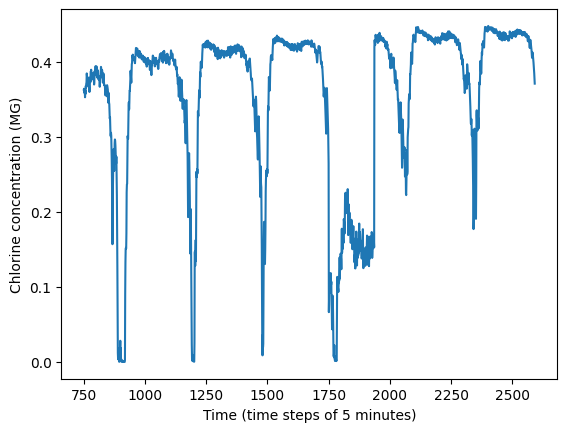

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
# df_global = pd.read_csv(".\\data_ageing_network\\scada_data_test_dist1915_110.csv")
# test 3 : voit un peu , test 30 : voit presque pas
# df = pd.read_csv(".\\data_hanoi\\scada_data_conta_3_test_1.csv")
df = pd.read_csv(".\\data_global_warming\\scada_data_test_dist606_15.csv")
# df2 = pd.read_csv(".\\data_cy\\scada_data_clean_3.csv")
# df3 = pd.read_csv(".\\data_cy\\scada_data_clean_4.csv")
# df4 = pd.read_csv(".\\data_cy\\scada_data_clean_7.csv")
# df5 = pd.read_csv(".\\data_cy\\scada_data_clean_9.csv")
# df_clean1 = pd.read_csv(".\\data_small_chlorine\\scada_data_clean_1.csv")
# df_clean2 = pd.read_csv(".\\data_small_chlorine\\scada_data_clean_3.csv")
# df_clean3 = pd.read_csv(".\\data_small_chlorine\\scada_data_clean_4.csv")
#df_2 = pd.read_csv(".\\data_arsenic\\scada_data_clean_1.csv")
# df = pd.read_csv(".\\data_arsenic\\scada_data_clean_1.csv")
# df_2 = pd.read_csv(".\\data_arsenic\\scada_data_conta_node_423_test_1.csv")

node_id = "dist420"
column_name = f"bulk_species_node [MG] at Chlorine @ {node_id}"

def plot_time_series(df, node):
    column_name_cl = f"bulk_species_node [MG] at Chlorine @ {node}"
    if column_name_cl in df.columns:
        df[column_name_cl][750:].plot()
        # add labels 
        plt.xlabel("Time (time steps of 5 minutes)")
        plt.ylabel("Chlorine concentration (MG)")
        # plt.ylabel("Values over time")
        plt.savefig("chlo_anomaly.pdf")
    else:
        print(f"Column {column_name_cl} not found in DataFrame.")
        
node = "dist606"
# plot_time_series(df_global, node)
plot_time_series(df, node)
# plot_time_series(df, "21")
# plot_time_series(df, "13")
# plot_time_series(df, "21")
# plot_time_series(df, "22")
# plot_time_series(df, "23")
# plot_time_series(df, "31")
# plot_time_series(df, "32")
# plot_time_series(df1, node)
# plot_time_series(df2, node)
# plot_time_series(df3, node)
# plot_time_series(df4, node)
# plot_time_series(df5, node)

In [21]:
import pandas as pd
df_path = ".\\data_small_chlorine_temp\\scada_data_train_4_1.csv"
df1 = pd.read_csv(df_path)

nodes = ["dist64", "dist356", "dist399", "dist420", "dist485", "dist606", "dist1028", "dist1332", "dist1363", "dist1459", "dist1464", "dist1915"]
# remove columns where not one of the nodes is present 
columns_to_keep = []
for node in nodes: 
    for col in df1.columns:
        if node in col:
            columns_to_keep.append(col)
df1 = df1[columns_to_keep]
print(df1.columns)
# print the columns of the dataframe
# save the dataframe to a csv file
df1.to_csv(df_path, index=False)

Index(['bulk_species_node [MG] at P @ dist64',
       'bulk_species_node [MG] at P @ dist648',
       'bulk_species_node [MG] at Chlorine @ dist64',
       'bulk_species_node [MG] at Chlorine @ dist648',
       'bulk_species_node [MG] at P @ dist356',
       'bulk_species_node [MG] at Chlorine @ dist356',
       'bulk_species_node [MG] at P @ dist399',
       'bulk_species_node [MG] at Chlorine @ dist399',
       'bulk_species_node [MG] at P @ dist420',
       'bulk_species_node [MG] at Chlorine @ dist420',
       'bulk_species_node [MG] at P @ dist485',
       'bulk_species_node [MG] at Chlorine @ dist485',
       'bulk_species_node [MG] at P @ dist606',
       'bulk_species_node [MG] at Chlorine @ dist606',
       'bulk_species_node [MG] at P @ dist1028',
       'bulk_species_node [MG] at Chlorine @ dist1028',
       'bulk_species_node [MG] at P @ dist1332',
       'bulk_species_node [MG] at Chlorine @ dist1332',
       'bulk_species_node [MG] at P @ dist1363',
       'bulk_species_n

Classic gaussian noise : 

In [ ]:
import numpy as np
import pandas as pd

df_path = ".\\data_small_chlorine_temp\\scada_data_clean_1.csv"

mu=0.0
std = 0.02
def gaussian_noise(x,mu,std):
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    x_noisy = np.clip(x_noisy, a_min=0, a_max=None) # set negative values to 0
    return x_noisy 

df = pd.read_csv(df_path)
column_name = f"bulk_species_node [MG] at Chlorine @ dist1915"
node_id = "dist1363"
x_noisy = gaussian_noise(df[column_name].values, mu, std)
df_copy = df.copy()
df_copy[column_name] = x_noisy
plot_time_series(df_copy, node_id)
df = df_copy
# df_copy.to_csv(f".\\data_compet\\scada_data_clean_gaussian_noise_2.csv", index=False)

NameError: name 'plot_time_series' is not defined

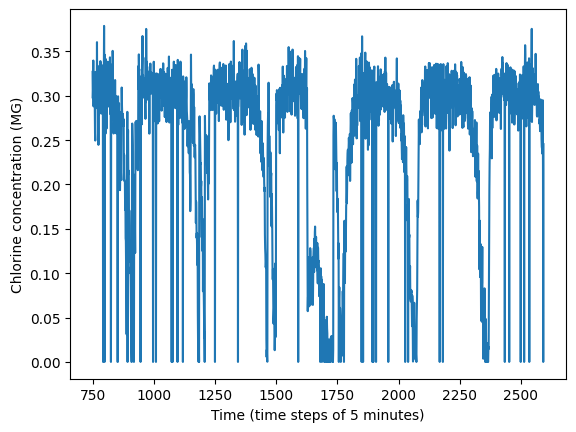

In [23]:
import numpy as np

def sensor_defect(x, pourcentage): 
    x_noised = x.copy()
    num_defects = int(pourcentage * len(x))
    defect_indices = np.random.choice(len(x), num_defects, replace=False)
    x_noised[defect_indices] = 0
    return x_noised
column_name = f"bulk_species_node [MG] at Chlorine @ dist1028"
node_id = "dist1028"
df = pd.read_csv(".\\data_cy\\scada_data_test_6_noisy.csv")
x_defected = sensor_defect(df[column_name].values, 0.02)
df_defected = df.copy()
df_defected[column_name] = x_defected
plot_time_series(df_defected, node_id)
df_defected.to_csv(f".\\data_cy\\scada_data_test_6_noisy.csv", index=False)

In [ ]:
mu=0.0
def gaussian_noise(x,mu):
    std = 0.2 * np.std(x)
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    return x_noisy 

x_noisy = gaussian_noise(df[column_name].values, mu)
df_cop = df.copy()
df_cop[column_name] = x_noisy
plot_time_series(df_cop, node_id)
df_copy.to_csv(f".\\data_hanoi\\hanoi_scada_data_conta_node_{node_id}_gaussian_noise_2.csv", index=False)

Impusle noise : from https://medium.com/@ms_somanna/guide-to-adding-noise-to-your-data-using-python-and-numpy-c8be815df524

In [ ]:
def generate_impulse_noise(x):
    noise_sample = np.random.default_rng().uniform(0.1*min(x), 0.1*max(x), int(0.03*len(x)))
    zeros = np.zeros(len(x) - len(noise_sample))
    noise = np.concatenate([noise_sample, zeros])
    np.random.shuffle(noise)
    y_noised = x + noise
    
    return y_noised
    
x_noisy = generate_impulse_noise(df[column_name].values)
df_impulse = df.copy()
df_impulse[column_name] = x_noisy
plot_time_series(df_impulse, node_id)

Quantization noise : pas faire

In [ ]:
def generate_quantization_noise(x, noise_percentage):
        # Generating noise

    # Get the size of the independent variable
    x_size = len(x)

    # Determine the size of the noise based on the noise precentage
    noise_size = int(noise_percentage * x_size)

    # Randomly select indices for adding noise.
    random_indices = np.random.choice(x_size, noise_size)

    # Create a copy of the original data that serves as a template for the noised data.
    x_noised = x.copy()

    # Round-off values of the templated noised data at random indices, to obtain the final noised data.
    x_noised[random_indices] = np.rint(x_noised[random_indices])
    
    return x_noised

noise_percentage = 0.005

x_noisy = generate_quantization_noise(df[column_name].values, noise_percentage)
df_quantization = df.copy()
df_quantization[column_name] = x_noisy
plot_time_series(df_quantization, node_id)

ne pas faire cela car on dirait des anomalies, donc d'office ça va confondre

Flipping the time series :

In [ ]:
def flip_time_series(x):
    x_noise = []
    for data in x :
        data_flipped = -data
        x_noise.append(data_flipped)
    return x_noise

x_noisy = flip_time_series(df[column_name].values)
df_flipped = df.copy() 
df_flipped[column_name] = x_noisy
plot_time_series(df_flipped, node_id)
        

Scaling/capteurs mal calibrés : 

In [ ]:
def shift_x(x, alpha, beta):
    x_shifted = alpha * x + beta 
    return x_shifted

alpha = 5
beta = 2
x_shifted = shift_x(df[column_name].values, alpha, beta)
df_shifted = df.copy()
df_shifted[column_name] = x_shifted
plot_time_series(df_shifted, node_id)

Décalage de phase :

In [ ]:
def shift_time_x(x, delta):
    x_shifted = np.roll(x, delta) 
    return x_shifted
delta = 200
x_shifted = shift_time_x(df[column_name].values, delta)
df_time_shifted = df.copy()
df_time_shifted[column_name] = x_shifted
plot_time_series(df_time_shifted, node_id)

add random sensor values at zero : pareil, on dirait des anomalies 

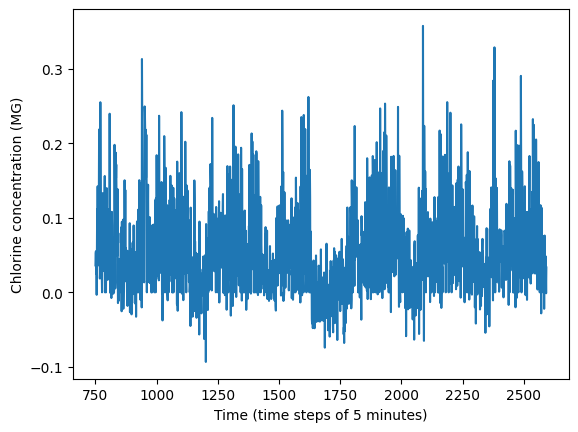

In [45]:
def sensor_defect(x, pourcentage): 
    x_noised = x.copy()
    num_defects = int(pourcentage * len(x))
    defect_indices = np.random.choice(len(x), num_defects, replace=False)
    x_noised[defect_indices] = 0
    return x_noised

x_defected = sensor_defect(df[column_name].values, 0.07)
df_defected = df.copy()
df_defected[column_name] = x_defected
plot_time_series(df_defected, node_id)


In [ ]:
import pandas as pd

df = pd.read_csv(".\\data_arsenic\\scada_data_conta_22_cleaned.csv")

def display_time_series(df, node):
    column_name_cl = "chlorine_concentration"
    df_filtered = df[df['node'] == node]
    if column_name_cl in df_filtered.columns:
        column_abscisse = df_filtered['timestep']
        column_ordonnee = df_filtered[column_name_cl]
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(column_abscisse, column_ordonnee)
        plt.title(f"Time series of Chlorine concentration at node {node}")
    else:
        print(f"Column {column_name_cl} not found in DataFrame.")


In [ ]:
dfs = [pd.read_csv(".\\data_arsenic\\scada_data_conta_22.csv"), pd.read_csv(".\\data_arsenic\\scada_data_conta_node_13.csv")]


node_id = "dist33"
column_name = f"bulk_species_node [MG] at Chlorine @ {node_id}"

# def plot_time_series(df, node):
#     column_name_cl = f"bulk_species_node [MG] at Chlorine @ {node}"
#     if column_name_cl in df.columns:
#         df[column_name_cl].plot(title=f"Time series of Chlorine concentration at node {node}")
#     else:
#         print(f"Column {column_name_cl} not found in DataFrame.")

nodes = ["22", "23"]

features = []
for df in dfs: 
    time_series = []
    for node in nodes: 
        column_name_cl = f"bulk_species_node [MG] at Chlorine @ {node}"
        if column_name_cl in df.columns:
            time_serie = df[column_name_cl].values
            time_series.append(time_serie)
        else:
            print(f"Column {column_name_cl} not found in DataFrame.")
    for time_serie in time_series: 
        feature = create_features(time_serie)
    
            
# [[1, 1, 1], [2, 2, 2], [3, 3, 3]],
# [[4, 4, 4], [5, 5, 5], [6, 6, 6]],
        

